# TU3 orbit around Sun

In [1]:
# Load standard modules
import numpy as np
from matplotlib import pyplot as plt

# Load tudatpy modules
from tudatpy.interface import spice
from tudatpy import dynamics
from tudatpy.dynamics import environment_setup, propagation_setup, propagation, simulator
from tudatpy import constants
from tudatpy.astro import element_conversion
from tudatpy.util import result2array
from tudatpy.astro.time_representation import DateTime

In [2]:
import re

params = {}

with open("horizons_results.txt", "r") as file:
    text = file.read()

matches = re.findall(r"([A-Z]+)=\s*([^\s]+)", text)

for key, value in matches:
    try:
        params[key] = float(value)
    except ValueError:
        # skip things like 'n.a.' or dates
        continue

orbit = {
    "semi_major_axis": params.get("A"),
    "eccentricity": params.get("EC"),
    "inclination": params.get("IN"),
    "argument_of_periapsis": params.get("W"),
    "longitude_of_ascending_node": params.get("OM"),
    "mean_anomaly": params.get("MA")
}

print(orbit)

{'semi_major_axis': 0.787092782297079, 'eccentricity': 0.4838099016687703, 'inclination': 5.412722178648383, 'argument_of_periapsis': 84.68464223297437, 'longitude_of_ascending_node': 102.1970210319019, 'mean_anomaly': 354.8400089926715}


In [3]:
semi_major_axis = orbit["semi_major_axis"]
eccentricity = orbit["eccentricity"]
inclination = orbit["inclination"]
argument_of_periapsis = orbit["argument_of_periapsis"]
longitude_of_ascending_node = orbit["longitude_of_ascending_node"]
mean_anomaly = orbit["mean_anomaly"]

# angles: deg → rad
inclination = np.deg2rad(inclination)
argument_of_periapsis = np.deg2rad(argument_of_periapsis)
longitude_of_ascending_node = np.deg2rad(longitude_of_ascending_node)
mean_anomaly = np.deg2rad(mean_anomaly)

# AU → meters
AU = 1.495978707e11
semi_major_axis = semi_major_axis * AU

In [4]:
def mean_to_true_anomaly(M, e, tol=1e-10):
    import numpy as np
    
    # solve for eccentric anomaly E using Newton-Raphson
    E = M
    for _ in range(100):
        E_new = E - (E - e*np.sin(E) - M) / (1 - e*np.cos(E))
        if abs(E_new - E) < tol:
            break
        E = E_new

    # convert to true anomaly
    nu = 2 * np.arctan2(
        np.sqrt(1 + e) * np.sin(E / 2),
        np.sqrt(1 - e) * np.cos(E / 2)
    )
    return nu

true_anomaly = mean_to_true_anomaly(mean_anomaly, eccentricity)

In [5]:
# Load spice kernels
spice.load_standard_kernels()

# Set simulation start and end epochs (total simulation time of 5 years)
simulation_start_epoch = DateTime(2025, 4, 25).to_epoch()
simulation_end_epoch   = simulation_start_epoch + 5 * constants.JULIAN_YEAR

In [6]:
# Define bodies in simulation
bodies_to_create = [
    "Sun"
]
bodies_to_propagate = ["TU3"]

# Create bodies in simulation.
body_settings = environment_setup.get_default_body_settings(bodies_to_create)
body_settings.add_empty_settings("TU3")
body_system = environment_setup.create_system_of_bodies(body_settings)

In [7]:
central_bodies = ["Sun"]
acceleration_settings_TU3 = dict(
    Sun=[propagation_setup.acceleration.point_mass_gravity()]
)

acceleration_settings = {"TU3": acceleration_settings_TU3}

# Create acceleration models
acceleration_models = propagation_setup.create_acceleration_models(
    body_system, acceleration_settings, bodies_to_propagate, central_bodies
)

In [8]:
# Set initial conditions for the satellite that will be
# propagated in this simulation. The initial conditions are given in
# Keplerian elements and later on converted to Cartesian elements
#GVK: what is the gravitational parameter? For example what is its purpose and what are its units?
sun_gravitational_parameter = body_system.get("Sun").gravitational_parameter
initial_state = element_conversion.keplerian_to_cartesian_elementwise(
    gravitational_parameter=sun_gravitational_parameter,
    semi_major_axis=semi_major_axis,
    eccentricity=eccentricity,
    inclination=inclination,
    argument_of_periapsis=argument_of_periapsis,
    longitude_of_ascending_node=longitude_of_ascending_node,
    true_anomaly=true_anomaly,
)

In [9]:
# Create termination settings
termination_settings = propagation_setup.propagator.time_termination(simulation_end_epoch)

# Create numerical integrator settings
#GVK: what are the time_step units?
integrator_settings = propagation_setup.integrator.runge_kutta_fixed_step(
    time_step = 3600.0,
    coefficient_set = propagation_setup.integrator.CoefficientSets.rk_4 )

# Create propagation settings
propagator_settings = propagation_setup.propagator.translational(
    central_bodies,
    acceleration_models,
    bodies_to_propagate,
    initial_state,
    simulation_start_epoch,
    integrator_settings,
    termination_settings
)

In [10]:
# Create simulation object and propagate the dynamics
dynamics_simulator = simulator.create_dynamics_simulator(
    body_system, propagator_settings
)
# Extract the resulting state history and convert it to an ndarray
states = dynamics_simulator.propagation_results.state_history
states_array = result2array(states)

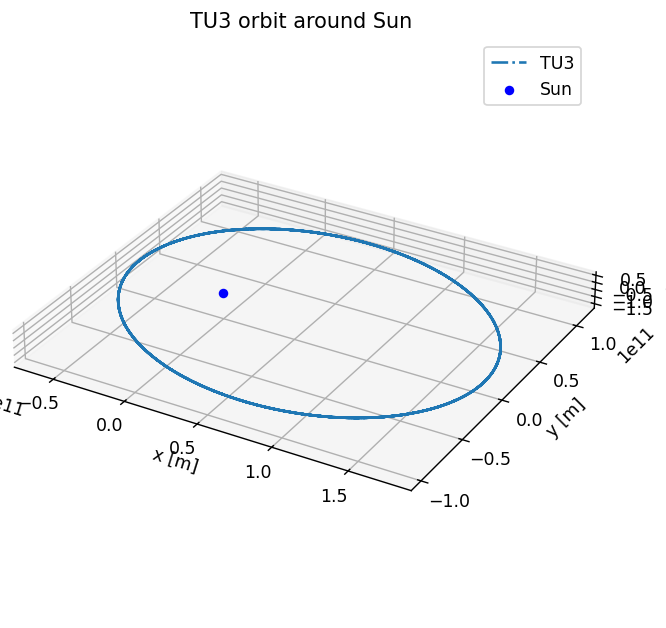

In [11]:
# Define a 3D figure using pyplot
fig = plt.figure(figsize=(6,6), dpi=125)
ax = fig.add_subplot(111, projection='3d')
ax.set_title(f'TU3 orbit around Sun')

# Plot the positional state history
ax.plot(states_array[:, 1], states_array[:, 2], states_array[:, 3], label=bodies_to_propagate[0], linestyle='-.')
ax.scatter(0.0, 0.0, 0.0, label="Sun", marker='o', color='blue')

# Add the legend and labels, then show the plot
ax.legend()
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_zlabel('z [m]')
ax.set_aspect('equal')
plt.show()

# TU3 orbit around Sun + planet orbits

In [12]:
# Define bodies in simulation
bodies_to_create = [
    "Moon",
    "Earth",
    "Mars",
    "Venus",
    "Mercury",
    "Sun"
]
bodies_to_propagate = ["TU3"]

# Create bodies in simulation.
body_settings = environment_setup.get_default_body_settings(bodies_to_create)
body_settings.add_empty_settings("TU3")
body_system = environment_setup.create_system_of_bodies(body_settings)

In [13]:
# Central bodies for barycentric propagation
# GVK: what is the definition of barycentric propagation? For example: what are the forces included and relative to what point are the movements specified?
central_bodies_barycentric = ["SSB"] * len(bodies_to_create)

# Central bodies for hierarchical parent body propagation
central_bodies_hierarchical = []
for body_name in bodies_to_create:
    if body_name == "Moon":
        central_bodies_hierarchical.append("Earth")
    elif body_name == "Sun":
        central_bodies_hierarchical.append("SSB")
    else:
        central_bodies_hierarchical.append("Sun")

In [14]:
bodies_to_propagate = ["TU3"]
central_bodies = ["Sun"]

#GVK: why did you choose point_mass_gravity? What were the options to choose from?
acceleration_dict = {
    "TU3": {
        body: [propagation_setup.acceleration.point_mass_gravity()]
        for body in bodies_to_create
    }
}

acceleration_models = propagation_setup.create_acceleration_models(
    body_system=body_system,
    selected_acceleration_per_body=acceleration_dict,
    bodies_to_propagate=bodies_to_propagate,
    central_bodies=central_bodies
)

In [15]:
# Use your previously computed Cartesian state of TU3
# (from keplerian_to_cartesian_elementwise)

system_initial_state = initial_state

for propagation_variant in ["barycentric", "hierarchical"]:
    
    if propagation_variant == "barycentric":
        system_initial_state_barycentric = initial_state
    else:
        system_initial_state_hierarchical = initial_state

In [16]:
#GVK: what is the difference between central_bodies and bodies_to_propagate?
bodies_to_propagate = ["TU3"]
central_bodies = ["Sun"]

propagator_settings = propagation_setup.propagator.translational(
    central_bodies,
    acceleration_models,
    bodies_to_propagate,
    system_initial_state,
    simulation_start_epoch,
    integrator_settings,
    termination_settings
)

results = simulator.create_dynamics_simulator(
    body_system, propagator_settings
).state_history

In [17]:
times = list(results.keys())
states = list(results.values())

times = np.array(times)
states = np.array(states)

# position only (x, y, z)
tu3_positions = states[:, 0:3]

def get_body_positions(body_name):
    body = body_system.get(body_name)
    return np.array([
        body.state_in_base_frame_from_ephemeris(t)[0:3]
        for t in times
    ])

earth_pos = get_body_positions("Earth")
mars_pos = get_body_positions("Mars")
venus_pos = get_body_positions("Venus")
mercury_pos = get_body_positions("Mercury")
sun_pos = get_body_positions("Sun")

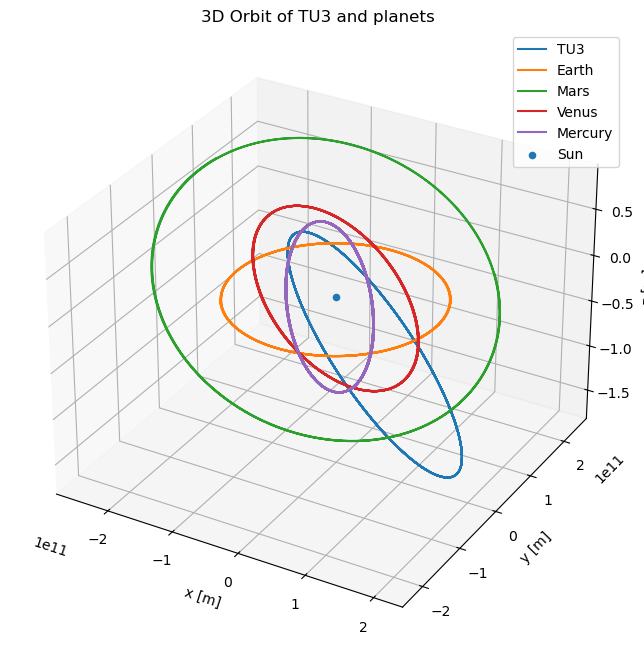

In [18]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# TU3
ax.plot(tu3_positions[:,0], tu3_positions[:,1], tu3_positions[:,2], label="TU3")

# Planets
ax.plot(earth_pos[:,0], earth_pos[:,1], earth_pos[:,2], label="Earth")
ax.plot(mars_pos[:,0], mars_pos[:,1], mars_pos[:,2], label="Mars")
ax.plot(venus_pos[:,0], venus_pos[:,1], venus_pos[:,2], label="Venus")
ax.plot(mercury_pos[:,0], mercury_pos[:,1], mercury_pos[:,2], label="Mercury")

# Sun
ax.scatter(0.0, 0.0, 0.0, label="Sun", marker='o')

# Labels
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]")

ax.legend()
ax.set_title("3D Orbit of TU3 and planets")

plt.show()

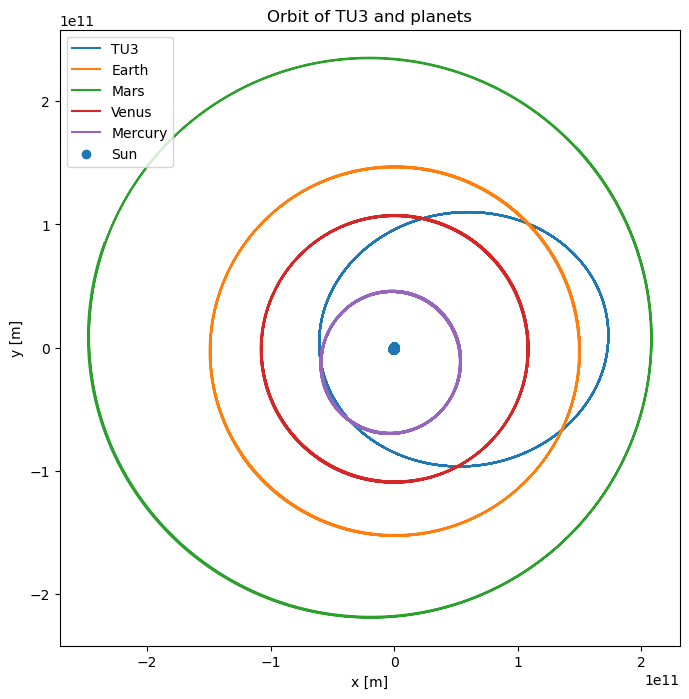

In [19]:
plt.figure(figsize=(8, 8))

# TU3
plt.plot(tu3_positions[:,0], tu3_positions[:,1], label="TU3")

# Planets
plt.plot(earth_pos[:,0], earth_pos[:,1], label="Earth")
plt.plot(mars_pos[:,0], mars_pos[:,1], label="Mars")
plt.plot(venus_pos[:,0], venus_pos[:,1], label="Venus")
plt.plot(mercury_pos[:,0], mercury_pos[:,1], label="Mercury")

# Sun (should be near origin)
plt.scatter(sun_pos[:,0], sun_pos[:,1], label="Sun", marker="o")

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.legend()
plt.axis("equal")
plt.title("Orbit of TU3 and planets")
plt.show()

In [20]:
# Load required standard modules
import numpy as np
from matplotlib import pyplot as plt

# Load required tudatpy modules
from tudatpy import constants
from tudatpy.interface import spice
from tudatpy import dynamics
from tudatpy.dynamics import environment, environment_setup
from tudatpy.dynamics import propagation_setup, parameters_setup, simulator
from tudatpy import estimation
from tudatpy.estimation import observable_models_setup, observable_models, observations_setup, observations, estimation_analysis
from tudatpy.astro.time_representation import DateTime
from tudatpy.astro import element_conversion

In [22]:
# Load spice kernels
spice.load_standard_kernels()

# Set simulation start and end epochs
simulation_start_epoch = DateTime(2025, 1, 5).to_epoch()
simulation_end_epoch   = DateTime(2030, 1, 5).to_epoch()

observation_start_epoch = DateTime(2026, 5, 1).to_epoch()
observation_end_epoch   = DateTime(2026, 5, 31).to_epoch()

results = simulator.create_dynamics_simulator(
    body_system, propagator_settings
).state_history

results_array = result2array(results)

times_sim = results_array[:, 0]

print(min(times_sim), max(times_sim))


798854400.0 956642400.0


In [23]:
parameter_settings = dynamics.parameters_setup.initial_states(
    propagator_settings, body_system
)

parameters_to_estimate = dynamics.parameters_setup.create_parameter_set(
    parameter_settings, body_system
)

In [24]:
times = []
ra_list = []
dec_list = []

inside_table = False

with open("horizons_results.txt") as f:
    for line in f:

        if "$$SOE" in line:
            inside_table = True
            continue

        if "$$EOE" in line:
            break

        if not inside_table:
            continue

        parts = line.split()

        if len(parts) < 8:
            continue  # skip malformed lines

        try:
            # time
            time_str = parts[0] + " " + parts[1]

            # RA
            h, m, s = map(float, parts[2:5])
            ra_deg = 15 * (h + m/60 + s/3600)

            # DEC
            sign = -1 if parts[5].startswith('-') else 1
            d = float(parts[5])
            m = float(parts[6])
            s = float(parts[7])
            dec_deg = sign * (abs(d) + m/60 + s/3600)

            times.append(time_str)
            ra_list.append(np.deg2rad(ra_deg))
            dec_list.append(np.deg2rad(dec_deg))

        except ValueError:
            # skip anything that still doesn't parse cleanly
            continue

from tudatpy.astro.time_representation import DateTime

months = {
    "Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4,
    "May": 5, "Jun": 6, "Jul": 7, "Aug": 8,
    "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12
}


In [25]:
epochs = []

for t in times:
    date_part, time_part = t.split()

    year, month_str, day = date_part.split("-")
    hour, minute = time_part.split(":")

    dt = DateTime(
        int(year),
        months[month_str],
        int(day),
        int(hour),
        int(minute),
        0
    )

    epochs.append(dt.epoch())

observations = np.vstack((ra_list, dec_list)).T
epochs = np.array(epochs)

In [26]:
#compute RA/DEC at observ time
def compute_model_radec(body_system, times):
    model = []

    for t in times:
        state = body_system.get("TU3").state_in_base_frame_from_ephemeris(t)
        r = state[0:3]

        x, y, z = r
        r_norm = np.linalg.norm(r)

        dec = np.arcsin(z / r_norm)
        ra = np.arctan2(y, x)

        model.append([ra, dec])

    return np.array(model)

In [28]:
from scipy.interpolate import interp1d

results_array = result2array(results)

times_sim = results_array[:, 0]
positions_sim = results_array[:, 1:4]

interp_x = interp1d(times_sim, positions_sim[:, 0], kind='cubic')
interp_y = interp1d(times_sim, positions_sim[:, 1], kind='cubic')
interp_z = interp1d(times_sim, positions_sim[:, 2], kind='cubic')

positions_obs = np.vstack((
    interp_x(epochs),
    interp_y(epochs),
    interp_z(epochs)
)).T

def cartesian_to_radec(r):
    x, y, z = r
    r_norm = np.linalg.norm(r)

    dec = np.arcsin(z / r_norm)
    ra = np.arctan2(y, x)

    return ra, dec

earth_positions = np.array([
    body_system.get("Earth").state_in_base_frame_from_ephemeris(t)[0:3]
    for t in epochs
])

relative_positions = positions_obs - earth_positions

model_radec = np.array([cartesian_to_radec(r) for r in relative_positions])

residuals = model_radec - observations

In [29]:

model_radec = compute_model_radec(body_system, epochs)

residuals = model_radec - observations

rmse = np.sqrt(np.mean(residuals**2, axis=0))

print("RA uncertainty:", rmse[0])
print("DEC uncertainty:", rmse[1])

RuntimeError: Error when setting global state of TU3 from ephemeris.
Original error: Error when requesting state from ephemeris of body TU3, body has no ephemeris